# Import Library

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

# Membaca Dataset

In [3]:
iris = pd.read_csv("data/IRIS.csv")
x = iris.iloc[:, [0, 1, 2, 3]].values

# Menampilkan Informasi Dataset

In [4]:
iris.info()
iris[0:10]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


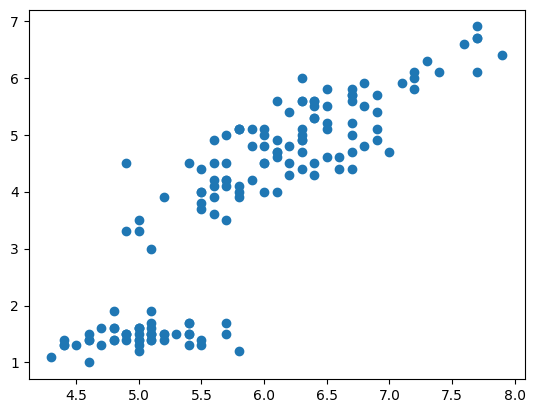

In [5]:
x_axis=iris.loc[:,['sepal_length']]
y_axis=iris.loc[:,['petal_length']]
plt.scatter(x_axis,y_axis)

# Distribusi Frekuensi dari Spesies yang Ada

In [6]:
iris_outcome = pd.crosstab(index=iris["species"],  # Make a crosstab
                              columns="count")      # Name the count column

iris_outcome

col_0,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


# Memisahkan Dataset Iris Berdasarkan Spesies

In [7]:
iris_setosa=iris.loc[iris["species"]=="Iris-setosa"]
iris_virginica=iris.loc[iris["species"]=="Iris-virginica"]
iris_versicolor=iris.loc[iris["species"]=="Iris-versicolor"]

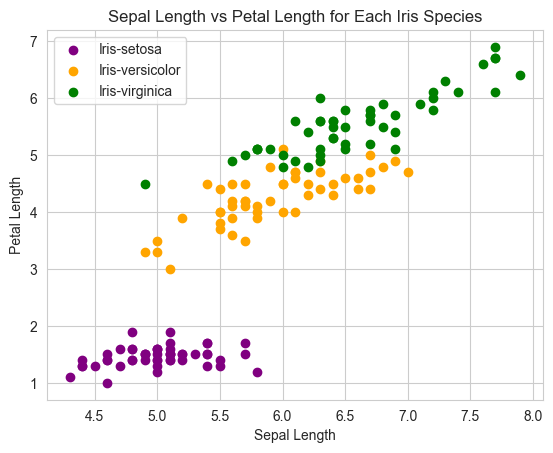

In [23]:
plt.scatter(iris_setosa['sepal_length'], iris_setosa['petal_length'], color='purple', label='Iris-setosa')
plt.scatter(iris_versicolor['sepal_length'], iris_versicolor['petal_length'], color='orange', label='Iris-versicolor')
plt.scatter(iris_virginica['sepal_length'], iris_virginica['petal_length'], color='green', label='Iris-virginica')

plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend()
plt.title('Sepal Length vs Petal Length for Each Iris Species')
plt.show()

# Distribution Plots

## Plot Setiap Bunga ke dalam Histogram

d:\data_mining\.venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
d:\data_mining\.venv\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
d:\data_mining\.venv\Lib\site-packages

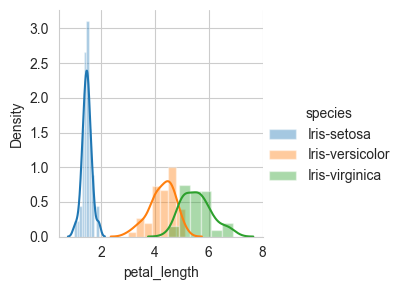

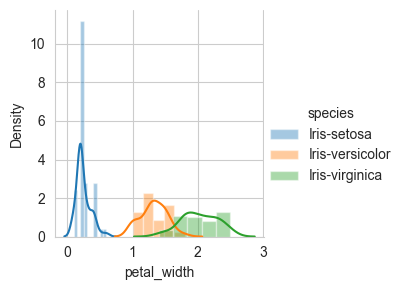

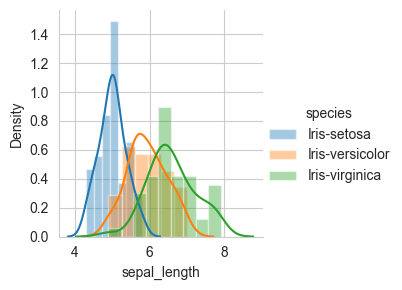

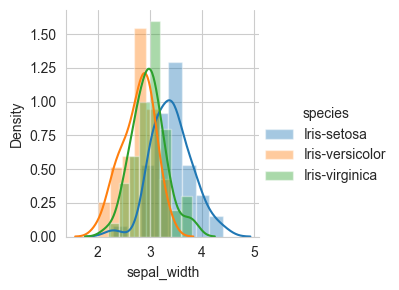

In [24]:
sns.FacetGrid(iris,hue="species",height=3).map(sns.distplot,"petal_length").add_legend()
sns.FacetGrid(iris,hue="species",height=3).map(sns.distplot,"petal_width").add_legend()
sns.FacetGrid(iris,hue="species",height=3).map(sns.distplot,"sepal_length").add_legend()
sns.FacetGrid(iris,hue="species",height=3).map(sns.distplot,"sepal_width").add_legend()
plt.show()

## Box Plot

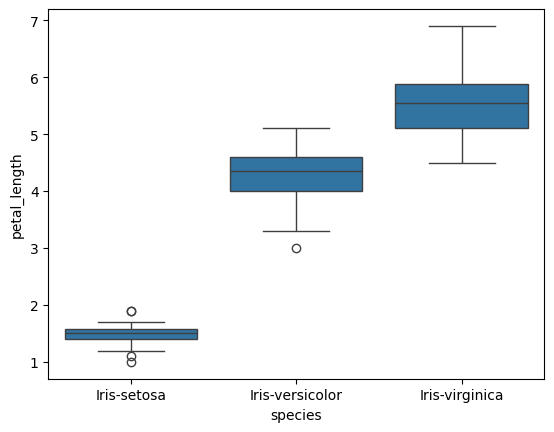

In [9]:
sns.boxplot(x="species",y="petal_length",data=iris)
plt.show()

## Violin Plot

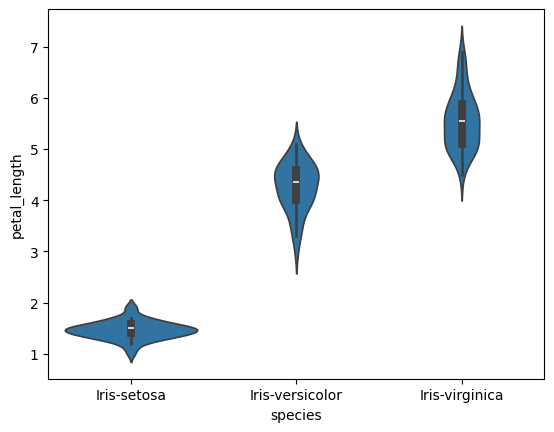

In [10]:
sns.violinplot(x="species",y="petal_length",data=iris)
plt.show()

## Scatter Plot

d:\data_mining\.venv\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


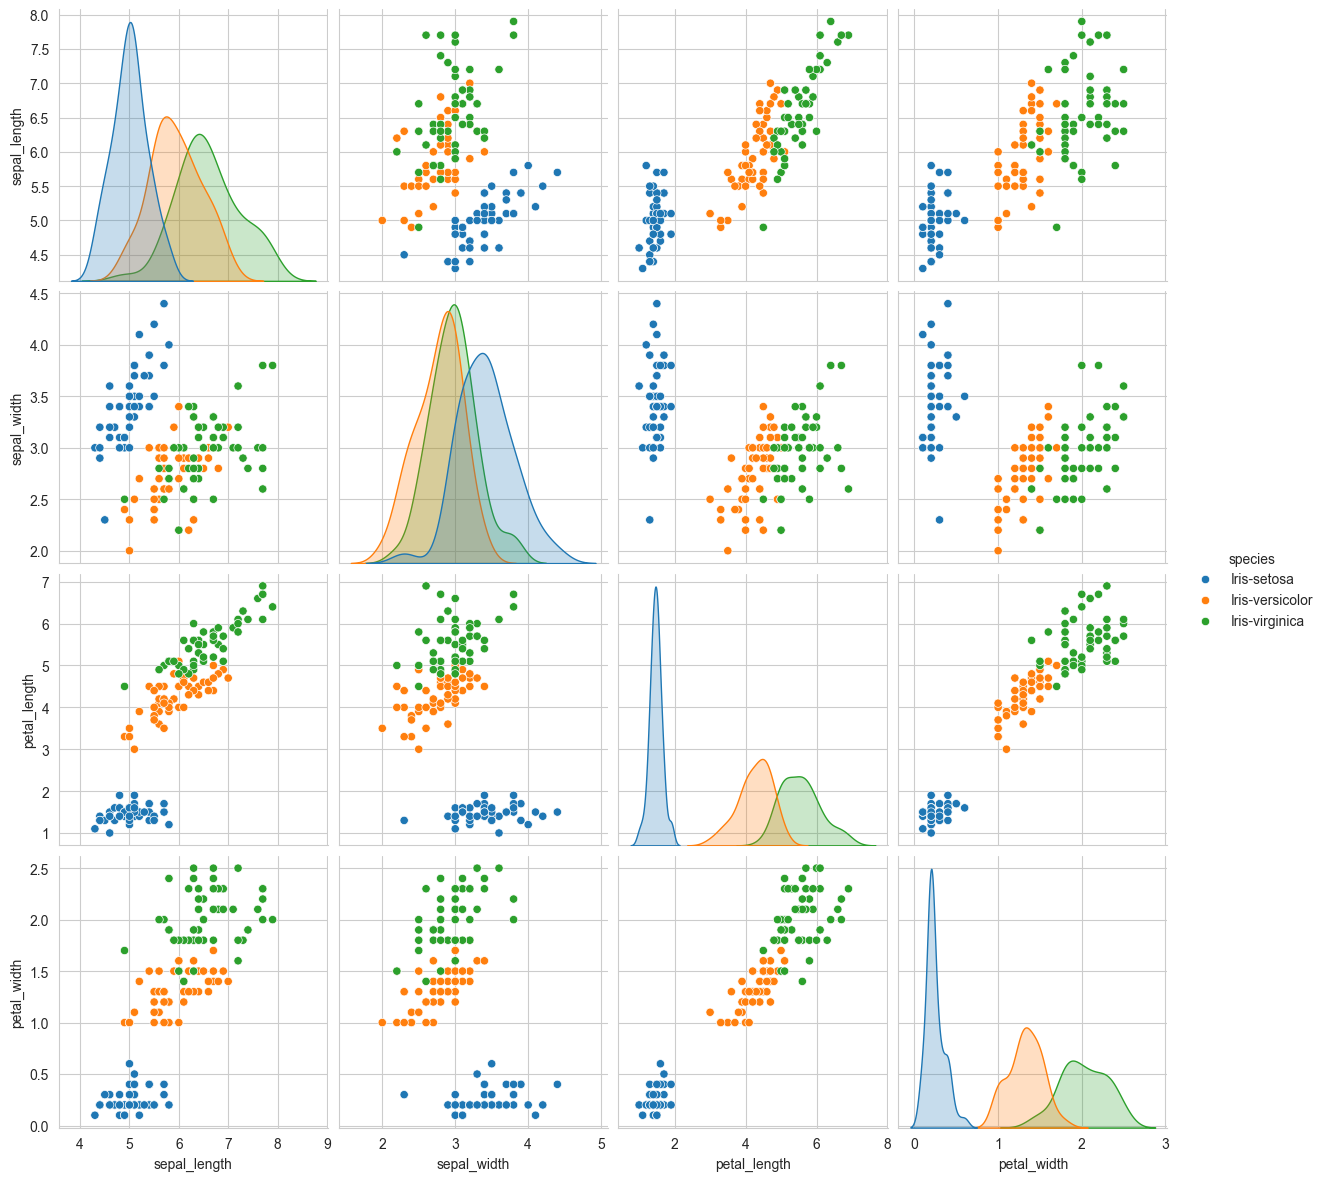

In [11]:
sns.set_style("whitegrid")
sns.pairplot(iris,hue="species",size=3);
plt.show()

# K-Means

## Menemukan Jumlah Optimal dari Cluster untuk Klasifikasi K-Means

In [12]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
    
pred = kmeans.predict(x)

In [13]:
pred

array([7, 2, 2, 2, 7, 0, 2, 7, 2, 2, 0, 7, 2, 2, 0, 0, 0, 7, 0, 7, 7, 7,
       2, 7, 7, 2, 7, 7, 7, 2, 2, 7, 0, 0, 2, 2, 7, 2, 2, 7, 7, 2, 2, 7,
       7, 2, 7, 2, 7, 7, 4, 4, 4, 3, 4, 6, 4, 8, 4, 3, 8, 6, 3, 6, 3, 4,
       6, 3, 6, 3, 1, 6, 1, 6, 4, 4, 4, 4, 6, 3, 3, 3, 3, 1, 6, 6, 4, 6,
       6, 3, 6, 6, 3, 8, 6, 6, 6, 6, 8, 6, 5, 1, 5, 5, 5, 9, 6, 9, 5, 9,
       5, 1, 5, 1, 1, 5, 5, 9, 9, 1, 5, 1, 9, 1, 5, 9, 1, 1, 5, 5, 9, 9,
       5, 1, 1, 9, 5, 5, 1, 5, 5, 5, 1, 5, 5, 5, 1, 5, 5, 1], dtype=int32)

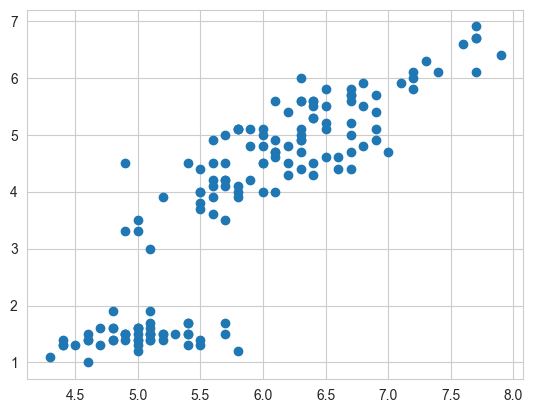

In [20]:
x_axis=iris.loc[:,['sepal_length']]
y_axis=iris.loc[:,['petal_length']]
plt.scatter(x_axis,y_axis)

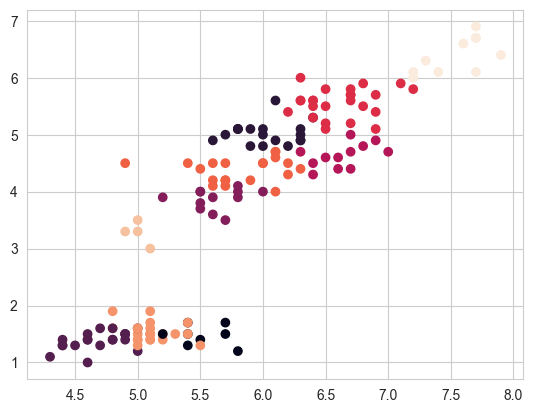

In [19]:
plt.scatter(x_axis, y_axis, c=pred)

## Menggunakan Elbow Method untuk Menentukan Jumlah Optimal dari Cluster untuk K-Means Clustering

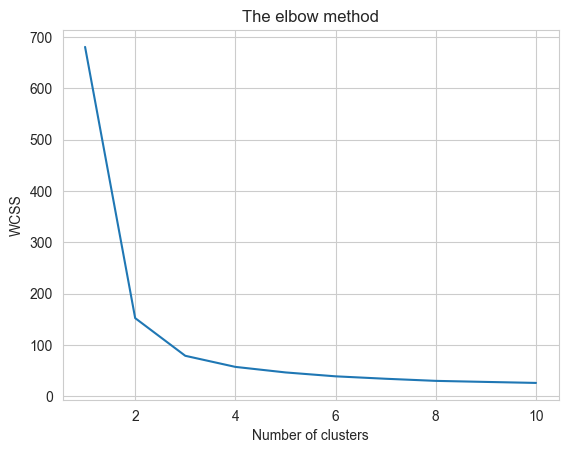

In [14]:
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') #within cluster sum of squares
plt.show()

## Implementasi K-Means CLustering

In [15]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(x)

In [25]:
y_kmeans

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

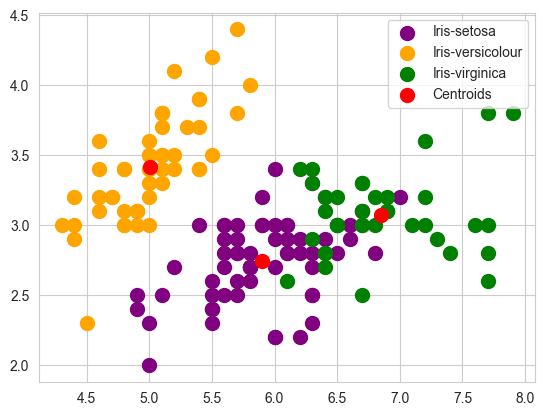

In [16]:
#Visualisi Cluster
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s = 100, c = 'purple', label = 'Iris-setosa')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s = 100, c = 'orange', label = 'Iris-versicolour')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Iris-virginica')

#Memplot centroid dari cluster
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], s = 100, c = 'red', label = 'Centroids')

plt.legend()

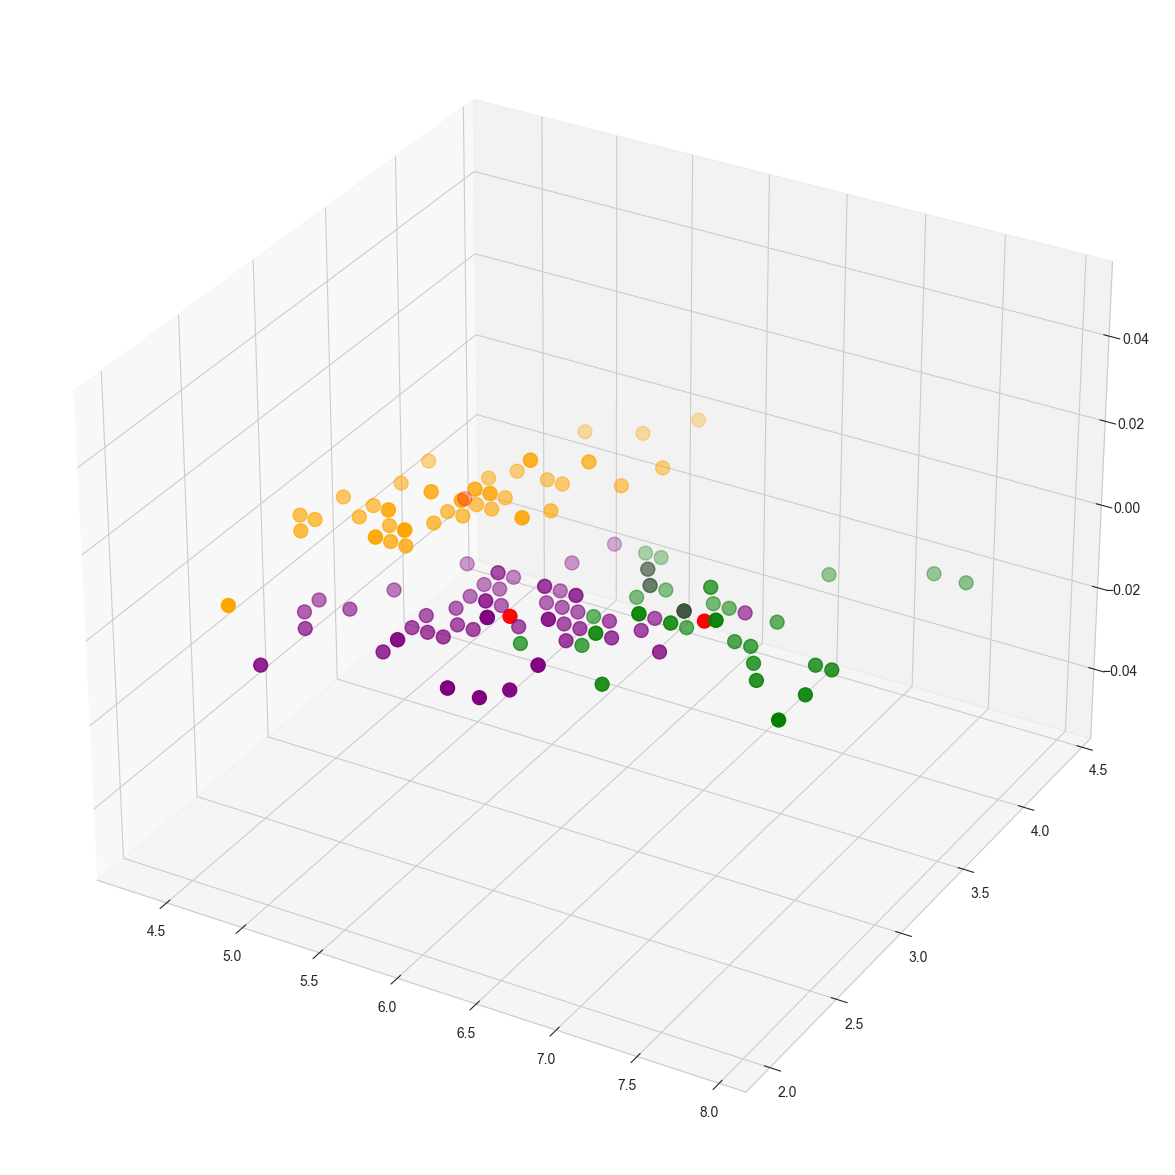

In [17]:
# 3d scatterplot menggunakan matplotlib
fig = plt.figure(figsize = (15,15))
ax = fig.add_subplot(111, projection='3d')
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s = 100, c = 'purple', label = 'Iris-setosa')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s = 100, c = 'orange', label = 'Iris-versicolour')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Iris-virginica')

# mem-plot centroid dari cluster
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], s = 100, c = 'red', label = 'Centroids')
plt.show()